# `Tarea 1: Reflexión Epistemológica

Fenomeno: como buscamos algo cuando se nos perdio

Cuando pierdes tus llaves por ejemplo tu busqueda no es de que en todos lados o random sigues donde pueden que haya estado


*   Primero vas a tu tocador o donde las dejas siempre
*   si no estan vas a donde las viste la ultima vez
*   preguntas a alguien si las vio
*   cuando te frustas te pones a volver a revisar donde ya checaste






## 2. Metáfora vs. Modelo Operativo

| Aspecto | Metáfora | Modelo formalizable |
|---|---|---|
| "Lugares donde siempre las dejo" | Hábito / memoria | Distribución de probabilidad prior `P(ubicación)` |
| "Reviso primero lo más probable" | Intuición | Muestreo por importancia |
| "Si no están, busco en otro lado" | Frustración | Actualización bayesiana |
| "Alguien me da una pista" | Información externa | Likelihood |
| "Revisito lugares ya vistos" | Duda / ruido | Probabilidad de detección < 1 |

Lo puramente metafórico: el estrés, la frustración, el “¿dónde las puse?!”

Lo completamente formalizable: este fenómeno es casi directamente la Búsqueda Bayesiana Óptima.

## 3. Heurística vs. Metaheurística

### Heurística simple

> "Revisa el lugar más probable primero, si no está pasa al siguiente."

### Metaheurística — Búsqueda Bayesiana Adaptativa

```python
1. INICIALIZAR mapa de probabilidades P(x) sobre todas las celdas/lugares
2. REPETIR hasta encontrar o agotar recursos:
   a. Elegir celda x* = argmax[ P(x) · valor_de_buscar(x) ]
   b. Buscar en x* con probabilidad de detección p_d < 1
   c. SI encontrado: terminar ✓
   d. SI no encontrado: ACTUALIZAR
         P(x*) ← P(x*) · (1 - p_d)        ← baja probabilidad de esa celda
         Renormalizar P(x) para que sume 1  ← sube probabilidad del resto
3. RETORNAR celda de mayor probabilidad acumulada
```

La clave: el mapa se actualiza con cada búsqueda fallida. No encontrarlo en la sala te dice algo — redistribuye probabilidad hacia la cocina, el carro, la bolsa del gym.

## 4. Comparación con Gradient Descent

| Dimensión | Gradient Descent | Búsqueda Bayesiana |
|---|---|---|
| Guía de búsqueda | Gradiente ∇f | Probabilidad posterior |
| Actualización | Determinista | Probabilística |
| Maneja incertidumbre | No | Sí |
| Revisita lugares | No | Sí |
| Información externa | No | Sí |
| Convergencia | Mínimo local | Objetivo esperado |

La diferencia clave: Gradient Descent sigue una dirección matemática precisa, mientras que la búsqueda bayesiana administra incertidumbre.

**Similitud clave:** ambos usan información acumulada para decidir hacia dónde moverse — GD usa el gradiente, Bayes usa el posterior.


**Diferencia clave:** GD nunca dice "tal vez me equivoqué antes". La búsqueda bayesiana vive de esa posibilidad.

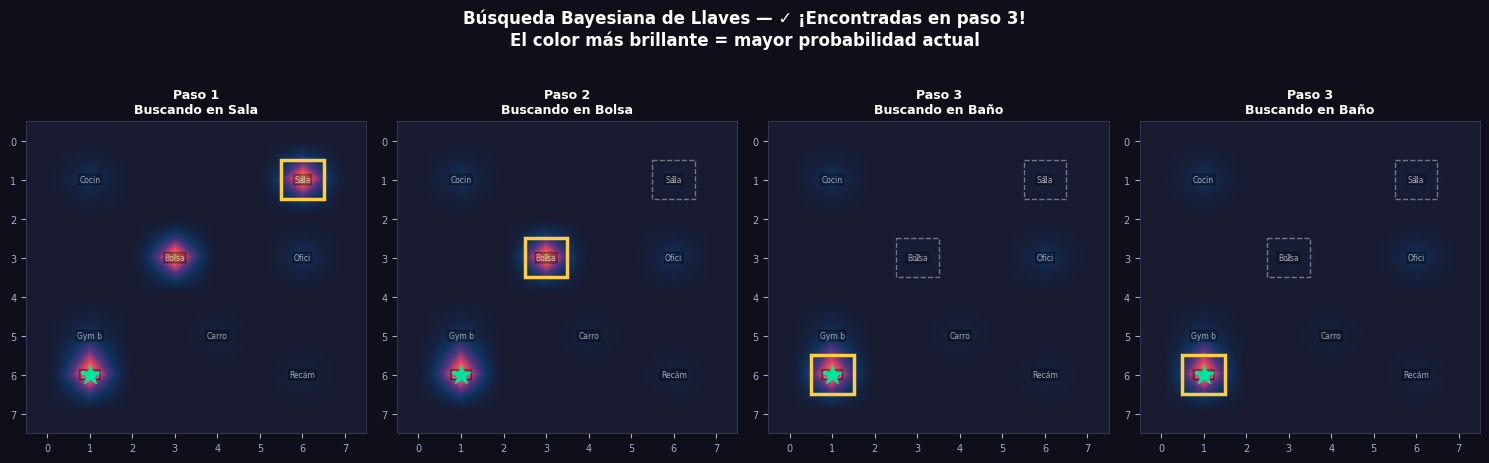

✓ Guardado | Pasos totales: 3 | ✓ ¡Encontradas en paso 3!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(42)

# ── Configuración del "cuarto" ─────────────────────────────────────────────
GRID = 8
lugares = {
    (1,6): "Sala",    (6,6): "Recámara", (1,1): "Cocina",
    (6,1): "Baño",    (3,3): "Bolsa",    (5,4): "Carro",
    (3,6): "Oficina", (5,1): "Gym bag"
}

# Prior: probabilidades iniciales por "lugar conocido"
prior = np.ones((GRID, GRID)) * 0.3
for (r,c), nombre in lugares.items():
    prior[r, c] = np.random.choice([3.0, 5.0, 8.0, 1.5])

# La llave está escondida en un lugar de baja probabilidad inicial
llave = (6, 1)   # "Baño" — nadie espera encontrarla ahí
P_deteccion = 0.85

# Normalizar
prob = prior / prior.sum()

historial = []
encontrado = False

for paso in range(25):
    # Elegir celda de mayor probabilidad
    celda = np.unravel_index(np.argmax(prob), prob.shape)
    historial.append((celda, prob.copy()))

    if celda == llave and np.random.rand() < P_deteccion:
        encontrado = True
        break

    # Actualizar: bajar probabilidad de celda revisada
    prob[celda] *= (1 - P_deteccion)
    prob /= prob.sum()   # renormalizar

# ── Figura ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
fig.patch.set_facecolor('#0f0f1a')

cmap = LinearSegmentedColormap.from_list(
    'bayes', ['#1a1a2e', '#16213e', '#0f3460', '#533483', '#e94560', '#f5a623'])

pasos_mostrar = [0, len(historial)//3, 2*len(historial)//3, len(historial)-1]

for idx, ax in enumerate(axes):
    paso_i = pasos_mostrar[idx]
    celda_i, prob_i = historial[paso_i]

    ax.set_facecolor('#1a1a2e')
    im = ax.imshow(prob_i, cmap=cmap, vmin=0, vmax=prob_i.max(),
                   aspect='auto', interpolation='bilinear')

    # Marcar celdas revisadas hasta este paso
    for j in range(paso_i + 1):
        c, _ = historial[j]
        ax.add_patch(mpatches.Rectangle(
            (c[1]-0.5, c[0]-0.5), 1, 1,
            fill=False, edgecolor='#ffffff', lw=1.0, alpha=0.4, linestyle='--'))
        ax.text(c[1], c[0], str(j+1), color='white',
                ha='center', va='center', fontsize=6.5, alpha=0.7)

    # Marcar celda actual
    ax.add_patch(mpatches.Rectangle(
        (celda_i[1]-0.5, celda_i[0]-0.5), 1, 1,
        fill=False, edgecolor='#ffcc44', lw=2.5))

    # Marcar la llave
    ax.scatter(llave[1], llave[0], s=200, color='#00e5a0',
               marker='*', zorder=10, label='🔑 Llave')

    # Etiquetas de lugares
    for (r,c), nombre in lugares.items():
        ax.text(c, r, nombre[:5], color='white', ha='center',
                va='center', fontsize=5.5, alpha=0.6,
                bbox=dict(boxstyle='round,pad=0.1', facecolor='#0f0f1a', alpha=0.3))

    ax.set_title(f'Paso {paso_i+1}\nBuscando en {lugares.get(celda_i, str(celda_i)[:5])}',
                 color='white', fontsize=9, fontweight='bold')
    ax.tick_params(colors='#aaaacc', labelsize=7)
    for spine in ax.spines.values():
        spine.set_color('#333355')

resultado = f"✓ ¡Encontradas en paso {len(historial)}!" if encontrado else "✗ No encontradas"
fig.suptitle(f'Búsqueda Bayesiana de Llaves — {resultado}\n'
             f'El color más brillante = mayor probabilidad actual',
             color='white', fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('busqueda_bayesiana_llaves.png',
            dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f"✓ Guardado | Pasos totales: {len(historial)} | {resultado}")